In [59]:
"""
| Description: libf0 SWIPE implementation
| Contributors: Sebastian Rosenzweig, Vojtěch Pešek, Simon Schwär, Meinard Müller
| License: The MIT license, https://opensource.org/licenses/MIT
| This file is part of libf0.
"""
from scipy import interpolate
import numpy as np
import librosa

small_primes = np.array([2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89,
                             97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181,
                             191, 193, 197, 199, 211, 223, 227, 229, 233, 239, 241, 251, 257, 263, 269, 271, 277, 281,
                             283, 293, 307, 311, 313, 317, 331, 337, 347, 349, 353, 359, 367, 373, 379, 383, 389, 397,
                             401, 409, 419, 421, 431, 433, 439, 443, 449, 457, 461, 463, 467, 479, 487, 491, 499, 503,
                             509, 521, 523, 541, 547, 557, 563, 569, 571, 577, 587, 593, 599, 601, 607, 613, 617, 619,
                             631, 641, 643, 647, 653, 659, 661, 673, 677, 683, 691, 701, 709, 719, 727, 733, 739, 743,
                             751, 757, 761, 769, 773, 787, 797, 809, 811, 821, 823, 827, 829, 839, 853, 857, 859, 863,
                             877, 881, 883, 887, 907, 911, 919, 929, 937, 941, 947, 953, 967, 971, 977, 983, 991, 997])

def primes(n):
    """Returns a set of n prime numbers"""

    b = small_primes <= n
    return small_primes[b]

def nyquist(Fs):
    """Nyquist Frequency"""
    return Fs / 2


def F_coef(k, N, Fs):
    """Physical frequency of STFT coefficients"""
    return (k * Fs) / N


def T_coef(m, H, Fs):
    """Physical time of STFT coefficients"""
    return m * H / Fs


def stft_with_f_t(y, N, H, Fs):
    """STFT wrapper"""
    x = librosa.stft(y, int(N), int(H), pad_mode='constant', center=True)
    f = F_coef(np.arange(0, x.shape[0]), N, Fs)
    t = T_coef(np.arange(0, x.shape[1]), H, Fs)

    return x, f, t


def hz2erbs(hz):
    """Convert Hz to ERB scale"""
    return 21.4 * np.log10(1 + hz / 229)


def erbs2hz(erbs):
    """Convert ERB to Hz"""
    return (10 ** np.divide(erbs, 21.4) - 1) * 229

def pitch_strength_one(erbs_frequencies, normalized_loudness, pitch_candidate):
    """Compute pitch strength for one pitch candidate"""
    number_of_harmonics = np.floor(erbs_frequencies[-1] / pitch_candidate - 0.75).astype(np.int32)
    k = np.zeros(erbs_frequencies.shape)

    # f_prime / f
    q = erbs_frequencies / pitch_candidate

    for i in np.concatenate(([1], primes(number_of_harmonics))):
        a = np.abs(q - i)
        p = a < 0.25
        k[p] = np.cos(np.dot(2 * np.pi, q[p]))
        v = np.logical_and(0.25 < a, a < 0.75)
        k[v] = k[v] + np.cos(np.dot(2 * np.pi, q[v])) / 2

    # Apply envelope
    k = np.multiply(k, np.sqrt(1.0 / erbs_frequencies))

    # K+-normalize kernel
    k = k / np.linalg.norm(k[k > 0])

    # Compute pitch strength
    S = np.dot(k, normalized_loudness)
    return S

def pitch_strength_all_candidates(ferbs, loudness, pitch_candidates):
    """Compute pitch strength for all pitch candidates"""
    # Normalize loudness
    normalization_loudness = np.full_like(loudness, np.sqrt(np.sum(loudness * loudness, axis=0)))
    with np.errstate(divide='ignore', invalid='ignore'):
        loudness = loudness / normalization_loudness

    # Create pitch salience matrix
    S = np.zeros((len(pitch_candidates), loudness.shape[1]))

    for j in range(0, len(pitch_candidates)):
        S[j, :] = pitch_strength_one(ferbs, loudness, pitch_candidates[j])
    return S


# def resample_ferbs(spectrum, f, ferbs):
#     """Resample to ERB scale"""
#     magnitude = np.zeros((len(ferbs), spectrum.shape[1]))

#     for t in range(spectrum.shape[1]):
#         spl = interpolate.splrep(f, spectrum[:, t])
#         interpolate.splev(ferbs, spl)

#         magnitude[:, t] = interpolate.splev(ferbs, spl)

#     return np.maximum(magnitude, 0)

def resample_ferbs(spectrum, f, ferbs):
    magnitude = np.empty((len(ferbs), spectrum.shape[1]), dtype=spectrum.dtype)

    for t in range(spectrum.shape[1]):
        magnitude[:, t] = np.interp(ferbs, f, spectrum[:, t])

    return np.maximum(magnitude, 0)


# def interpolate_one_candidate(pitch_strength, ti, resampled_time):
#     """Interpolate time axis"""
#     pitch_strength_interpolated = np.zeros((pitch_strength.shape[0], len(resampled_time)))

#     for s in range(pitch_strength.shape[0]):
#         t_i = interpolate.interp1d(ti, pitch_strength[s, :], 'linear', bounds_error=True)
#         pitch_strength_interpolated[s, :] = t_i(resampled_time)

#     return pitch_strength_interpolated

def interpolate_one_candidate(pitch_strength, ti, resampled_time):
    out = np.empty((pitch_strength.shape[0], len(resampled_time)), dtype=pitch_strength.dtype)
    for s in range(pitch_strength.shape[0]):
        out[s, :] = np.interp(resampled_time, ti, pitch_strength[s, :])
    return out

def resample_time(pitch_strength, resampled_time, ti):
    """Resample time axis"""
    if pitch_strength.shape[1] > 0:
        pitch_strength = interpolate_one_candidate(pitch_strength, ti, resampled_time)
    else:
        pitch_strength = np.kron(np.ones((len(pitch_strength), len(resampled_time))), np.nan)
    return pitch_strength

def parabolic_int(pitch_strength, strength_threshold, pc):
    """Parabolic interpolation between pitch candidates using pitch strength"""
    p = np.full((pitch_strength.shape[1],), np.nan)
    s = np.full((pitch_strength.shape[1],), np.nan)

    for j in range(pitch_strength.shape[1]):
        i = np.argmax(pitch_strength[:, j])
        s[j] = pitch_strength[i, j]

        if s[j] < strength_threshold:
            continue

        if i == 0:
            p[j] = pc[0]
        elif i == len(pc) - 1:
            p[j] = pc[0]
        else:
            I = np.arange(i - 1, i + 2)
            tc = 1 / pc[I]
            ntc = np.dot((tc / tc[1] - 1), 2 * np.pi)
            if np.any(np.isnan(pitch_strength[I, j])):
                s[j] = np.nan
                p[j] = np.nan
            else:
                c = np.polyfit(ntc, pitch_strength[I, j], 2)
                ftc = 1 / 2 ** np.arange(np.log2(pc[I[0]]), np.log2(pc[I[2]]), 1 / 12 / 64)
                nftc = np.dot((ftc / tc[1] - 1), 2 * np.pi)
                poly = np.polyval(c, nftc)
                k = np.argmax(poly)
                s[j] = poly[k]
                p[j] = 2 ** (np.log2(pc[I[0]]) + k / 12 / 64)
    return p, s

def swipe(x, Fs=22050, H=256, F_min=55.0, F_max=1760.0, dlog2p=1 / 96, derbs=0.1, strength_threshold=0):
    """
    Implementation of a sawtooth waveform inspired pitch estimator (SWIPE).
    This version of the algorithm follows the original implementation, see `swipe_slim` for a more efficient
    alternative.

    .. [#] Arturo Camacho and John G. Harris,
       "A sawtooth waveform inspired pitch estimator for speech and music."
       The Journal of the Acoustical Society of America, vol. 124, no. 3, pp. 1638–1652, Sep. 2008

    Parameters
    ----------
    x : ndarray
        Audio signal
    Fs : int
        Sampling rate
    H : int
        Hop size
    F_min : float or int
        Minimal frequency
    F_max : float or int
        Maximal frequency
    dlog2p : float
        resolution of the pitch candidate bins in octaves (default value = 1/96 -> 96 bins per octave)
    derbs : float
        resolution of the ERB bands (default value = 0.1)
    strength_threshold : float
        confidence threshold [0, 1] for the pitch detection (default value = 0)

    Returns
    -------
    f0 : ndarray
        Estimated F0-trajectory
    t : ndarray
        Time axis
    strength : ndarray
        Confidence/Pitch Strength
    """
    # print("UP TO DATE")
    t = np.arange(0, len(x), H) / Fs  # Times

    # Compute pitch candidates
    pc = 2 ** np.arange(np.log2(F_min), np.log2(F_max), dlog2p)

    # Pitch strength matrix
    S = np.zeros((len(pc), len(t)))

    # Determine P2-WSs [max, min]
    log_ws_max = np.ceil(np.log2((8 / F_min) * Fs))
    log_ws_min = np.floor(np.log2((8 / F_max) * Fs))

    # P2-WSs - window sizes in samples
    ws = 2 ** np.arange(log_ws_max, log_ws_min - 1, -1, dtype=np.int32)
    # print(f'window sizes in samples: {ws}')

    # Determine window sizes used by each pitch candidate
    log2pc = np.arange(np.log2(F_min), np.log2(F_max), dlog2p)
    d = log2pc - np.log2(np.divide(8 * Fs, ws[0]))

    # Create ERBs spaced frequencies (in Hertz)
    fERBs = erbs2hz(np.arange(hz2erbs(pc[0] / 4), hz2erbs(Fs / 2), derbs))

    for i in range(0, len(ws)):
        N = ws[i]
        H = int(N / 2)

        x_zero_padded = np.concatenate([x, np.zeros(N)])

        X = librosa.stft(x_zero_padded, n_fft=N, hop_length=H, pad_mode='constant', center=True)
        ti = librosa.frames_to_time(np.arange(0, X.shape[1]), sr=Fs, hop_length=H, n_fft=N)
        f = librosa.fft_frequencies(sr=Fs, n_fft=N)

        ti = np.insert(ti, 0, 0)
        ti = np.delete(ti, -1)

        spectrum = np.abs(X)
        magnitude = resample_ferbs(spectrum, f, fERBs)
        loudness = np.sqrt(magnitude)

        # Select candidates that use this window size
        # First window
        if i == 0:
            j = np.argwhere(d < 1).flatten()
            k = np.argwhere(d[j] > 0).flatten()
        # Last Window
        elif i == len(ws) - 1:
            j = np.argwhere(d - i > -1).flatten()
            k = np.argwhere(d[j] - i < 0).flatten()
        else:
            j = np.argwhere(np.abs(d - i) < 1).flatten()
            k = np.arange(0, len(j))

        pc_to_compute = pc[j]

        pitch_strength = pitch_strength_all_candidates(fERBs, loudness, pc_to_compute)

        resampled_pitch_strength = resample_time(pitch_strength, t, ti)

        lambda_ = d[j[k]] - i
        mu = np.ones(len(j))
        mu[k] = 1 - np.abs(lambda_)

        S[j, :] = S[j, :] + np.multiply(
            np.ones(resampled_pitch_strength.shape) * mu.reshape((mu.shape[0], 1)),
            resampled_pitch_strength
        )

    # Fine-tune the pitch using parabolic interpolation
    pitches, strength = parabolic_int(S, strength_threshold, pc)

    # pitches[np.where(np.isnan(pitches))] = 0  # avoid NaN output

    return pitches, t, strength


In [60]:
import numpy as np
import matplotlib.pyplot as plt
#%matplotlib qt
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from pathlib import Path
import os
from scipy.io import wavfile
from pathlib import Path

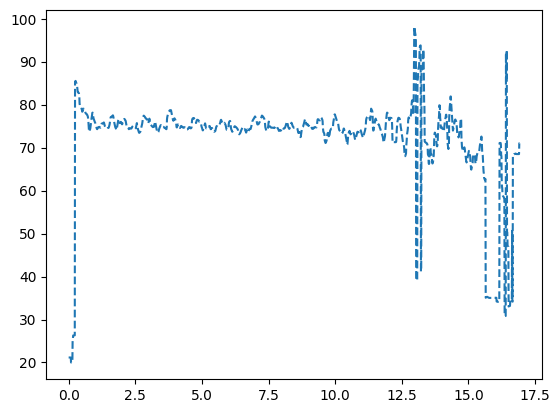

In [61]:
group = "PN"
sample_name = "PN652a1"

sample_rate, signal = wavfile.read(f"{group}/prodlouzena_fonace/{sample_name}.wav")
data_PRAAT = np.loadtxt(f"praat_pitches/vowels/{group}/Pitch {sample_name}.txt", delimiter="\t")

times_PRAAT = data_PRAAT[:, 0]
pitch_PRAAT = data_PRAAT[:, 1]

min_freq = np.min(pitch_PRAAT[np.isfinite(pitch_PRAAT)])
max_freq = np.max(pitch_PRAAT[np.isfinite(pitch_PRAAT)])
freq_range = 30

H = int(0.01 * sample_rate) # time_step = 10 ms
F_min, F_max = max(min_freq-freq_range, 20), (max_freq+freq_range)
pitch_SWIPE, times_SWIPE, _ = swipe(signal, sample_rate, H, F_min, F_max, dlog2p=1 / 48, derbs=0.2, strength_threshold=0)

time_step_SWIPE = np.round(np.median(np.diff(times_SWIPE)), 4)

plt.figure()
plt.plot(times_SWIPE, pitch_SWIPE, "--")


In [62]:
def interpolate_pitch(pitch):
    pitch = pitch.copy()
    pitch = np.array(pitch)
    pitch[pitch <= 0] = np.nan
    valid = np.isfinite(pitch) & (pitch > 0)

    if np.sum(valid) < 2:
        return pitch

    pitch_interp = np.interp(
        np.arange(len(pitch)),
        np.where(valid)[0],
        pitch[valid]
    )

    return pitch_interp

def getFrameXt(pitch, frame_idx, n_side, fref_mode): # maybe test win_len: 100 ms, 150 ms, 200 ms, 300 ms

    win_start = frame_idx-n_side
    win_end = frame_idx+n_side
    # print(f"start: {win_start}, end: {win_end}")
    window_pitch = pitch[win_start:win_end+1]

    local_frame_idx = n_side
    if np.isnan(window_pitch[local_frame_idx]):
        return None
    
    window_pitch_valid = window_pitch[(~np.isnan(window_pitch)) & (window_pitch > 0)]
    # if len(window_pitch_valid) < 3:
    #     return None

    # print(window_pitch)
    # print(window_pitch_valid)
    
    if fref_mode == "upper_60_80_median":
        p60 = np.percentile(window_pitch_valid, 60)
        p80 = np.percentile(window_pitch_valid, 80)
        fref = np.median(window_pitch_valid[(window_pitch_valid >= p60) & (window_pitch_valid <= p80)])
    elif fref_mode == "upper_70_90_median":
        p70 = np.percentile(window_pitch_valid, 70)
        p90 = np.percentile(window_pitch_valid, 90)
        fref = np.median(window_pitch_valid[(window_pitch_valid >= p70) & (window_pitch_valid <= p90)])
    elif fref_mode == "upper_80_90_median":
        p80 = np.percentile(window_pitch_valid, 80)
        p90 = np.percentile(window_pitch_valid, 90)
        fref = np.median(window_pitch_valid[(window_pitch_valid >= p80) & (window_pitch_valid <= p90)])
    elif fref_mode == "median": # median
        fref = np.median(window_pitch_valid)
    else:
        raise ValueError("Unsupported fref_mode")
    
    # print(f"f_ref = {fref}")
    if not np.isfinite(fref) or fref <= 0:
        return None
    x_frame = np.log2(window_pitch[local_frame_idx]/fref)
    # print(np.log2(window_pitch/fref))
    # print(x_frame)
    return x_frame


def getXtFrames(pitch, first_frame_idx, last_frame_idx, n_side, fref_mode):
    x_frames = []
    for frame_idx in range(first_frame_idx, last_frame_idx+1):
        x_t = getFrameXt(pitch, frame_idx, n_side, fref_mode)
        if x_t is None:
            print("NONE")
        x_frames.append(x_t)
    
    return np.array(x_frames)

In [63]:
def gaussian_pdf(x, mu, sigma):
    sigma = max(float(sigma), 1e-6)
    return (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def em_two_fixed_means(x_frames, prior_non_init, prior_sub_init, max_iter=200, tol=1e-4, sigma_floor=0.05,
                       mu_non=0.0, mu_sub=-1.0, sigma_non_init=0.15, sigma_sub_init=0.15,
                       ):
    
    x = np.asarray(x_frames, dtype=float)
    x = x[np.isfinite(x)]

    if x.size < 5:
        raise ValueError("Not enough valid x_t samples for EM.")

    prior_non = float(prior_non_init)
    prior_sub = float(prior_sub_init)
    sigma_non = max(float(sigma_non_init), sigma_floor)
    sigma_sub = max(float(sigma_sub_init), sigma_floor)

    prev_posterior_sub = None

    for i in range(max_iter):
        # print(f"ITERATION {i+1}")

        # E-step
        p_non = prior_non * gaussian_pdf(x, mu_non, sigma_non)
        p_sub = prior_sub * gaussian_pdf(x, mu_sub, sigma_sub)
      
        posterior_non = p_non / (p_non + p_sub + 1e-12)
        posterior_sub = p_sub / (p_non + p_sub + 1e-12)

        # convergence check right after E-step
        if prev_posterior_sub is not None:
            max_posterior_change = np.max(np.abs(posterior_sub - prev_posterior_sub))
            # print(f"max posterior change = {max_posterior_change:.5f}")

            if max_posterior_change < tol:
                # print(f"Stopping: max posterior change = {max_posterior_change:.5f}")
                break
        
        prev_posterior_sub = posterior_sub.copy()

        # M-step
        N_non = np.sum(posterior_non)
        N_sub = np.sum(posterior_sub)
        
        prior_non = N_non / x.size
        prior_sub = N_sub / x.size

        sigma_non = np.sqrt(np.sum(posterior_non * (x - mu_non) ** 2) / (N_non + 1e-12))
        sigma_non = max(float(sigma_non), sigma_floor)

        sigma_sub = np.sqrt(np.sum(posterior_sub * (x - mu_sub) ** 2) / (N_sub + 1e-12))
        sigma_sub = max(float(sigma_sub), sigma_floor)

        # print(
        #     f"prior_non={prior_non:.3f}, prior_sub={prior_sub:.3f}, "
        #     f"sigma_non={sigma_non:.4f}, sigma_sub={sigma_sub:.4f}"
        # )


    # final E-step with final parameters
    p_non = prior_non * gaussian_pdf(x, mu_non, sigma_non)
    p_sub = prior_sub * gaussian_pdf(x, mu_sub, sigma_sub)

    posterior_non = p_non / (p_non + p_sub + 1e-12)
    posterior_sub = p_sub / (p_non + p_sub + 1e-12)

    return {
        "prior_non": prior_non,
        "prior_sub": prior_sub,
        "mu_non": mu_non,
        "mu_sub": mu_sub,
        "sigma_non": sigma_non,
        "sigma_sub": sigma_sub,
        "posterior_non": posterior_non,
        "posterior_sub": posterior_sub,
    }

In [64]:
def smooth_posterior(posterior, win_len):
    """
    Simple moving average smoothing.
    win_len should usually be odd: 3, 5, 7...
    """
    posterior = np.asarray(posterior, dtype=float)

    if win_len <= 1:
        return posterior.copy()

    kernel = np.ones(win_len, dtype=float) / win_len
    posterior_smooth = np.convolve(posterior, kernel, mode="same")
    return posterior_smooth

def find_runs(labels):
    labels = np.asarray(labels, dtype=bool)
    runs = []

    if len(labels) == 0:
        return runs

    start = 0
    current = labels[0]

    for i in range(1, len(labels)):
        if labels[i] != current:
            runs.append((current, start, i - 1))
            start = i
            current = labels[i]

    runs.append((current, start, len(labels) - 1))
    return runs

def fill_short_gaps(labels, min_gap_frames):
    """
    If a zero-run between two positive runs is short enough,
    convert it to ones.
    """
    labels = np.asarray(labels, dtype=bool).copy()
    runs = find_runs(labels)

    for value, start, end in runs:
        run_len = end - start + 1

        if value == False and run_len <= min_gap_frames:
            left_is_sub = start > 0 and labels[start - 1]
            right_is_sub = end < len(labels) - 1 and labels[end + 1]

            if left_is_sub and right_is_sub:
                labels[start:end + 1] = True

    return labels

def remove_short_subharmonic_runs(labels, min_len_frames):
    """
    Remove positive runs that are shorter than min_len_frames.
    """
    labels = np.asarray(labels, dtype=bool).copy()
    runs = find_runs(labels)

    for value, start, end in runs:
        run_len = end - start + 1

        if value == True and run_len < min_len_frames:
            labels[start:end + 1] = False

    return labels

def labels_to_intervals(times, labels):
    intervals = []
    in_interval = False
    start_idx = None

    for i, lab in enumerate(labels):
        # Start of subharmonic interval reached
        if lab == True and in_interval == False:
            in_interval = True
            start_idx = i

        # End of subharmonic interval reached
        elif lab == False and in_interval == True:
            end_idx = i - 1
            intervals.append((times[start_idx], times[end_idx]))
            in_interval = False

    # Subharmonic till the end
    if in_interval:
        intervals.append((times[start_idx], times[len(labels) - 1]))

    return intervals

def predAndPostProcessFrames(posteriors, decision_thresh, time_step, min_gap_frames, min_len_frames):
    smooth_span_sec = 0.05
    smooth_win_len = int(round(smooth_span_sec / time_step))
    if smooth_win_len % 2 == 0:
        smooth_win_len += 1
    smooth_win_len = max(smooth_win_len, 1)
    # print(f"Smooth win len for 50ms: {smooth_win_len} frames")

    # print(em["posterior_sub"].shape)
    posterior_smoothed = smooth_posterior(posteriors, smooth_win_len)
    # print(posterior_smoothed.shape)
    # print(time_frames.shape)
    frame_preds = (posterior_smoothed >= decision_thresh)
    # print(labels_sub.sum())

    frame_preds = fill_short_gaps(frame_preds, min_gap_frames)
    # print(f"After 1st gap filling: {np.sum(labels_sub)}")
    frame_preds = remove_short_subharmonic_runs(frame_preds, min_len_frames)
    # print(f"After removing short runs: {np.sum(labels_sub)}")
    frame_preds = fill_short_gaps(frame_preds, min_gap_frames)
    # print(f"After 2nd gap filling: {np.sum(labels_sub)}")

    return frame_preds

In [65]:
def interval_iou(a, b):
    a_start, a_end = a
    b_start, b_end = b

    # intersection
    inter = max(0, min(a_end, b_end) - max(a_start, b_start))

    # union
    union = (a_end - a_start) + (b_end - b_start) - inter

    return inter / union if union > 0 else 0.0


def greedy_match_intervals(labels, preds, iou_threshold):
    """
    Greedy one-to-one matching of label intervals and predicted intervals.

    Args:
        labels: list of (start, end)
        preds: list of (start, end)
        iou_threshold: minimum IoU required to allow a match

    Returns:
        matches: list of dicts with matched pairs
        unmatched_labels: list of dicts
        unmatched_preds: list of dicts
    """
    candidates = []

    # Compute all candidate matches
    for li, label in enumerate(labels):
        for pi, pred in enumerate(preds):
            iou = interval_iou(label, pred)
            if iou >= iou_threshold:
                candidates.append((iou, li, pi))

    # Best IoU first
    candidates.sort(key=lambda x: x[0], reverse=True)

    matched_label_idxs = set()
    matched_pred_idxs = set()
    matches = []

    for iou, li, pi in candidates:
        if li in matched_label_idxs or pi in matched_pred_idxs:
            continue

        matches.append({
            "label_idx": li,
            "pred_idx": pi,
            "label": labels[li],
            "pred": preds[pi],
            "iou": iou,
        })
        matched_label_idxs.add(li)
        matched_pred_idxs.add(pi)

    unmatched_labels = [
        {"label_idx": li, "label": labels[li]}
        for li in range(len(labels))
        if li not in matched_label_idxs
    ]

    unmatched_preds = [
        {"pred_idx": pi, "pred": preds[pi]}
        for pi in range(len(preds))
        if pi not in matched_pred_idxs
    ]

    return matches, unmatched_labels, unmatched_preds

In [66]:
def detectSubharmonics(data, interval_labels, sample_length, tmin_cutoff, win_len, fref_mode, min_gap_dur, min_subharm_dur):

    # print(interval_labels)
    times = data[:, 0]
    pitch = data[:, 1]
    pitch = interpolate_pitch(pitch)

    if len(times) != len(pitch):
        raise IndexError("Time indeces don't match pitch values!")

    time_step = np.round(np.median(np.diff(times)), 4)

    # win_len = 0.25 # 250 ms
    n_side = int(round((win_len / 2) / time_step))
    # print(n_side)
    # print(np.searchsorted(times, 1, side='left'))
    # print(len(times) - n_side -1)
    # print(np.searchsorted(times, sample_length-1, side='right') - 1)
    first_frame_idx = max(n_side, np.searchsorted(times, tmin_cutoff, side='left')) # frame_idx = np.searchsorted(times, times[0] + win_len/2)
    last_frame_idx = min(len(times) - n_side -1, np.searchsorted(times, sample_length-tmin_cutoff, side='right') - 1)
    # win_size = 2*n_side + 1

    x_frames = getXtFrames(pitch, first_frame_idx, last_frame_idx, n_side, fref_mode)
    time_frames = times[first_frame_idx:last_frame_idx+1]

    prior_non_init, prior_sub_init = 0.9, 0.1
    em = em_two_fixed_means(x_frames, prior_non_init, prior_sub_init)   

    # min_subharm_dur = 0.05
    # max_gap_dur = 0.5

    min_len_frames = int(np.ceil(min_subharm_dur / time_step))
    min_gap_frames = int(np.floor(min_gap_dur / time_step))
    # print(f"min_len_frames = {min_len_frames}")
    # print(f"max_gap_frames = {max_gap_frames}")

    decision_thresh = 0.5
    # labels_sub = (em["posterior_sub"] >= decision_thresh)
    # print(labels_sub.sum())

    frame_preds = predAndPostProcessFrames(em["posterior_sub"], decision_thresh, time_step, min_gap_frames, min_len_frames)

    interval_preds = labels_to_intervals(time_frames, frame_preds)
    # print(f"Total number of subharmonic intervals: {len(intervals)}")

    iou_threshold = 0.3
    matches, unmatched_labels, unmatched_preds = greedy_match_intervals(interval_labels, interval_preds, iou_threshold)

    TP = len(matches)
    FN = len(unmatched_labels)
    FP = len(unmatched_preds)

    return TP, FP, FN

In [67]:
def getAccuracy(TP, FP, FN):
    return TP / (TP + FP + FN) if (TP) > 0 else 0.0

def getPrecision(TP, FP):
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0

def getRecall(TP, FN):
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

def getF1(precision, recall):
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

In [68]:
recording_lengths = {}  

groups = ["HC", "RBD", "PN", "MSA"]
for group in groups:
    folder_path = Path(group)/"prodlouzena_fonace"
    if folder_path.exists():
        for file_path in folder_path.iterdir():
            if file_path.is_file() and file_path.suffix.lower() == ".wav":

                fs, data = wavfile.read(file_path)
                sample_name = file_path.stem

                rec_duration = len(data)/fs
                recording_lengths[sample_name] = rec_duration


df_labels = pd.read_csv("subharm_times.csv")

# fix missing sample names
df_labels["sample"] = df_labels["sample"].ffill()

labels_intervals = {}
subharm_group_counts = {"HC": 0, "RBD": 0, "PN": 0, "MSA": 0}

for sample, group_df in df_labels.groupby("sample"):
    # intervals = list(zip(group_df["tmin"], group_df["tmax"]))
    rec_len = recording_lengths[sample]
    intervals = [
                (tmin, tmax)
                for tmin, tmax in zip(group_df["tmin"], group_df["tmax"])
                if (tmin > 1) and (tmin < rec_len - 1)
                ]

    group_name = group_df["group"].iloc[0]  # same for whole sample
    subharm_group_counts[group_name] += len(intervals)

    labels_intervals[sample] = intervals # "group": group_name,

print("Total number of subharmonic labels per group:")
for g, gc in subharm_group_counts.items():
    print(f"{g}: {gc}")

Total number of subharmonic labels per group:
HC: 84
RBD: 44
PN: 144
MSA: 198


In [69]:
def runEpoch(win_len, fref_mode, min_gap, min_subharm_len):
    

    metrics = {"HC": {"TP": 0, "FP": 0, "FN": 0, "accuracy": 0, "precision": 0, "recall": 0, "F1": 0},
                       "RBD": {"TP": 0, "FP": 0, "FN": 0, "accuracy": 0, "precision": 0, "recall": 0, "F1": 0},
                       "PN": {"TP": 0, "FP": 0, "FN": 0, "accuracy": 0, "precision": 0, "recall": 0, "F1": 0},
                       "MSA": {"TP": 0, "FP": 0, "FN": 0, "accuracy": 0, "precision": 0, "recall": 0, "F1": 0},
                       "overall": {"TP": 0, "FP": 0, "FN": 0, "accuracy": 0, "precision": 0, "recall": 0, "F1": 0},}

    folder_path = Path("praat_pitches/vowels")
    if folder_path.exists():
        for subfolder in folder_path.iterdir():
            if subfolder.is_dir():
                
                group = subfolder.name
                # TP_total = 0
                # FP_total = 0
                # FN_total = 0
                for file_path in subfolder.iterdir():
                    
                    if file_path.is_file() and file_path.suffix == ".txt":
                        
                        
                        sample_name = file_path.name[len("Pitch "):-4]
                        sample_length = recording_lengths[sample_name]
                        # print(sample_name)

                        sample_rate, signal = wavfile.read(f"{group}/prodlouzena_fonace/{sample_name}.wav")
                        data_PRAAT = np.loadtxt(f"praat_pitches/vowels/{group}/Pitch {sample_name}.txt", delimiter="\t")
                        pitch_PRAAT = data_PRAAT[:, 1]

                        min_freq = np.min(pitch_PRAAT[np.isfinite(pitch_PRAAT)])
                        max_freq = np.max(pitch_PRAAT[np.isfinite(pitch_PRAAT)])
                        freq_range = 30

                        H = int(0.01 * sample_rate) # time_step = 10 ms
                        F_min, F_max = max(min_freq-freq_range, 20), max(max_freq+freq_range, 50)
                        pitch_SWIPE, times_SWIPE, _ = swipe(signal, sample_rate, H, F_min, F_max, dlog2p=1 / 48, derbs=0.2, strength_threshold=0)
                        data_SWIPE = np.column_stack((times_SWIPE, pitch_SWIPE))

                        sample_labels = labels_intervals[sample_name] if sample_name in labels_intervals else []
                        tmin_cutoff = 1.
                        TP, FP, FN = detectSubharmonics(data_SWIPE, sample_labels, sample_length, tmin_cutoff, win_len, fref_mode, min_gap, min_subharm_len)

                        metrics[group]["TP"] += TP
                        metrics[group]["FP"] += FP
                        metrics[group]["FN"] += FN

                accuracy = getAccuracy(metrics[group]["TP"], metrics[group]["FP"], metrics[group]["FN"])
                metrics[group]["accuracy"] = accuracy
                precision = getPrecision(metrics[group]["TP"], metrics[group]["FP"])
                metrics[group]["precision"] = precision
                recall = getRecall(metrics[group]["TP"], metrics[group]["FN"])
                metrics[group]["recall"] = recall
                f1 = getF1(precision, recall)
                metrics[group]["f1"] = f1

    for g in metrics:
        if g != "overall":
            metrics["overall"]["TP"] += metrics[g]["TP"]
            metrics["overall"]["FP"] += metrics[g]["FP"]
            metrics["overall"]["FN"] += metrics[g]["FN"]

    metrics["overall"]["accuracy"] = getAccuracy(metrics["overall"]["TP"], metrics["overall"]["FP"], metrics["overall"]["FN"])
    metrics["overall"]["precision"] = getPrecision(metrics["overall"]["TP"], metrics["overall"]["FP"])
    metrics["overall"]["recall"] = getRecall(metrics["overall"]["TP"], metrics["overall"]["FN"])
    metrics["overall"]["f1"] = getF1(metrics["overall"]["precision"], metrics["overall"]["recall"])

    return metrics

In [70]:
cutoffs = [1.0] #[0.8, 1.0, 1.2, 1.4, 1.6]
win_lengths = [0.15, 0.2, 0.25, 0.3, 0.35] # 0.1, 
fref_modes = ["upper_70_90_median"]#, "upper_80_90_median"] # "upper_60_80_median", 
EM_subharm_priors = [0.1]#, 0.5]
merge_gaps = [0.3, 0.4, 0.5, 0.6, 0.7]
min_subharm_lengths = [0.05, 0.1, 0.15, 0.2]
iou_threshs = [0.3] # 0.2, 

bestAccuracy, bestPrecision, bestRecall, bestF1 = 0., 0., 0., 0.
bestAccuracyIdx, bestPrecisionIdx, bestRecallIdx, bestF1Idx = None, None, None, None
bestAccuracyParams, bestPrecisionParams, bestRecallParams, bestF1Params = None, None, None, None

nIterations = len(cutoffs)*len(win_lengths)*len(fref_modes)*len(EM_subharm_priors)*len(merge_gaps)*len(min_subharm_lengths)*len(iou_threshs)
print(f"Total number of iterations: {nIterations}")

iter_metrics = []

counter = 1
# for co in cutoffs:
for wl in win_lengths:
    for fm in fref_modes:
        # for sp in EM_subharm_priors:
        for mg in merge_gaps:
            for msl in min_subharm_lengths:
                # for iout in iou_threshs:
                print(f"Iteration {counter}/{nIterations} with win_len = {wl}, fref_mode = {fm}, merge_gap={mg}, min_subharm_len={msl}")
                metrics = runEpoch(wl, fm, mg, msl)
                print(f"Iteration finished: accuracy {metrics["overall"]["accuracy"]:.3f}, precision {metrics["overall"]["precision"]:.3f}, recall {metrics["overall"]["recall"]:.3f}, F1 {metrics["overall"]["f1"]:.3f}")
                iter_metrics.append(metrics)
                if metrics["overall"]["accuracy"] > bestAccuracy:
                    bestAccuracy = metrics["overall"]["accuracy"]
                    bestAccuracyIdx = counter-1
                    bestAccuracyParams = {"wl": wl, "fm": fm, "mg": mg, "msl": msl}
                    print(f"NEW BEST ACCURACY {bestAccuracy:.3f}: win_len={wl}, fref_mode={fm}, min_gap={mg}, min_subharm_len={msl}")

                if metrics["overall"]["precision"] > bestPrecision:
                    bestPrecision = metrics["overall"]["precision"]
                    bestPrecisionIdx = counter-1
                    bestPrecisionParams = {"wl": wl, "fm": fm, "mg": mg, "msl": msl}
                    print(f"NEW BEST PRECISION {bestPrecision:.3f}: win_len={wl}, fref_mode={fm}, min_gap={mg}, min_subharm_len={msl}")

                if metrics["overall"]["recall"] > bestRecall:
                    bestRecall = metrics["overall"]["recall"]
                    bestRecallIdx = counter-1
                    bestRecallParams = {"wl": wl, "fm": fm, "mg": mg, "msl": msl}
                    print(f"NEW BEST RECALL {bestRecall:.3f}: win_len={wl}, fref_mode={fm}, min_gap={mg}, min_subharm_len={msl}")

                if metrics["overall"]["f1"] > bestF1:
                    bestF1 = metrics["overall"]["f1"]
                    bestF1Idx = counter-1
                    bestF1Params = {"wl": wl, "fm": fm, "mg": mg, "msl": msl}
                    print(f"NEW BEST F1 {bestF1:.3f}: win_len={wl}, fref_mode={fm}, min_gap={mg}, min_subharm_len={msl}")
                
                print()
                counter += 1
                
            
        
 

                
print("--------------FINISHED---------------")
print()
print("BEST PERFOMANCE PARAMETERS:")
print()
print(f"Best accuracy {bestAccuracy:.3f}: win_len={bestAccuracyParams["wl"]}, fref_mode={bestAccuracyParams["fm"]}, min_gap={bestAccuracyParams["mg"]}, min_subharm_len={bestAccuracyParams["msl"]}")
bestAccuracyMetrics = iter_metrics[bestAccuracyIdx]
for g in bestAccuracyMetrics:         
    print(f"---------{g}---------")
    print(f"TP for {g}:", bestAccuracyMetrics[g]["TP"])
    print(f"FP for {g}:", bestAccuracyMetrics[g]["FP"])
    print(f"FN for {g}:", bestAccuracyMetrics[g]["FN"])
    print(f"Accuracy for {g}: {bestAccuracyMetrics[g]["accuracy"]:.3f}")
    print(f"Precision for {g}: {bestAccuracyMetrics[g]["precision"]:.3f}")
    print(f"Recall for {g}: {bestAccuracyMetrics[g]["recall"]:.3f}")
    print(f"F1 for {g}: {bestAccuracyMetrics[g]["f1"]:.3f}")
print()

print(f"Best precision {bestPrecision:.3f}: win_len={bestPrecisionParams["wl"]}, fref_mode={bestPrecisionParams["fm"]}, min_gap={bestPrecisionParams["mg"]}, min_subharm_len={bestPrecisionParams["msl"]}")
bestPrecisionMetrics = iter_metrics[bestPrecisionIdx]
for g in bestPrecisionMetrics:         
    print(f"---------{g}---------")
    print(f"TP for {g}:", bestPrecisionMetrics[g]["TP"])
    print(f"FP for {g}:", bestPrecisionMetrics[g]["FP"])
    print(f"FN for {g}:", bestPrecisionMetrics[g]["FN"])
    print(f"Accuracy for {g}: {bestPrecisionMetrics[g]["accuracy"]:.3f}")
    print(f"Precision for {g}: {bestPrecisionMetrics[g]["precision"]:.3f}")
    print(f"Recall for {g}: {bestPrecisionMetrics[g]["recall"]:.3f}")
    print(f"F1 for {g}: {bestPrecisionMetrics[g]["f1"]:.3f}")
print()

print(f"Best recall {bestRecall:.3f}: win_len={bestRecallParams["wl"]}, fref_mode={bestRecallParams["fm"]}, min_gap={bestRecallParams["mg"]}, min_subharm_len={bestRecallParams["msl"]}")
bestRecallMetrics = iter_metrics[bestRecallIdx]
for g in bestRecallMetrics:         
    print(f"---------{g}---------")
    print(f"TP for {g}:", bestRecallMetrics[g]["TP"])
    print(f"FP for {g}:", bestRecallMetrics[g]["FP"])
    print(f"FN for {g}:", bestRecallMetrics[g]["FN"])
    print(f"Accuracy for {g}: {bestRecallMetrics[g]["accuracy"]:.3f}")
    print(f"Precision for {g}: {bestRecallMetrics[g]["precision"]:.3f}")
    print(f"Recall for {g}: {bestRecallMetrics[g]["recall"]:.3f}")
    print(f"F1 for {g}: {bestRecallMetrics[g]["f1"]:.3f}")
print()

print(f"Best F1 {bestF1:.3f}: win_len={bestF1Params["wl"]}, fref_mode={bestF1Params["fm"]}, min_gap={bestF1Params["mg"]}, min_subharm_len={bestF1Params["msl"]}")
bestF1Metrics = iter_metrics[bestF1Idx]
for g in bestF1Metrics:         
    print(f"---------{g}---------")
    print(f"TP for {g}:", bestF1Metrics[g]["TP"])
    print(f"FP for {g}:", bestF1Metrics[g]["FP"])
    print(f"FN for {g}:", bestF1Metrics[g]["FN"])
    print(f"Accuracy for {g}: {bestF1Metrics[g]["accuracy"]:.3f}")
    print(f"Precision for {g}: {bestF1Metrics[g]["precision"]:.3f}")
    print(f"Recall for {g}: {bestF1Metrics[g]["recall"]:.3f}")
    print(f"F1 for {g}: {bestF1Metrics[g]["f1"]:.3f}")

Total number of iterations: 100
Iteration 1/100 with win_len = 0.15, fref_mode = upper_70_90_median, merge_gap=0.3, min_subharm_len=0.05
Iteration finished: accuracy 0.292, precision 0.361, recall 0.604, F1 0.452
NEW BEST ACCURACY 0.292: win_len=0.15, fref_mode=upper_70_90_median, min_gap=0.3, min_subharm_len=0.05
NEW BEST PRECISION 0.361: win_len=0.15, fref_mode=upper_70_90_median, min_gap=0.3, min_subharm_len=0.05
NEW BEST RECALL 0.604: win_len=0.15, fref_mode=upper_70_90_median, min_gap=0.3, min_subharm_len=0.05
NEW BEST F1 0.452: win_len=0.15, fref_mode=upper_70_90_median, min_gap=0.3, min_subharm_len=0.05

Iteration 2/100 with win_len = 0.15, fref_mode = upper_70_90_median, merge_gap=0.3, min_subharm_len=0.1
Iteration finished: accuracy 0.310, precision 0.441, recall 0.511, F1 0.473
NEW BEST ACCURACY 0.310: win_len=0.15, fref_mode=upper_70_90_median, min_gap=0.3, min_subharm_len=0.1
NEW BEST PRECISION 0.441: win_len=0.15, fref_mode=upper_70_90_median, min_gap=0.3, min_subharm_len=

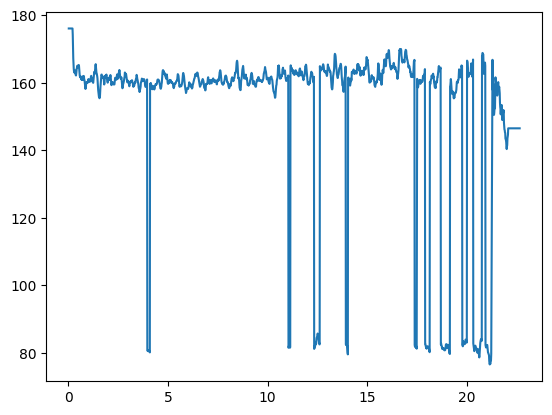

Time step: 0.0125


ValueError: Unsupported fref_mode

In [71]:
# Sample HC845i2 with 7 FPs
# Sample HC592i1 with 5 FPs
# Sample HC861a2 with 4 FPs
# Samples with an FN: 13
# Sample HC592i1 with 5 FNs
# Sample HC853i2 with 5 FNs
# Sample HC836i2 with 4 FNs

# Sample RBD204i1 with 5 FPs
# Sample RBD114a1 with 4 FPs
# Sample RBD130a1 with 3 FPs
# Samples with an FN: 5
# Sample RBD223a1 with 2 FNs
# Sample RBD114i1 with 1 FNs
# Sample RBD134i2 with 1 FNs

data = np.loadtxt("praat_pitches/vowels/HC/Pitch HC853i2.txt", delimiter="\t")

times = data[:, 0]
pitch = data[:, 1]
pitch = interpolate_pitch(pitch)
plt.figure()
plt.plot(times, pitch)
plt.show()

if len(times) != len(pitch):
    raise IndexError("Time indeces don't match pitch values!")

time_step = np.round(np.median(np.diff(times)), 4)
print(f"Time step: {time_step}")

win_len = 0.25 # 250 ms
n_side = int(round((win_len / 2) / time_step))
first_frame_idx = n_side # frame_idx = np.searchsorted(times, times[0] + win_len/2)
last_frame_idx = len(pitch) - n_side -1
# win_size = 2*n_side + 1

x_frames = []
for frame_idx in range(first_frame_idx, last_frame_idx+1):
    x_t = getFrameXt(pitch, frame_idx, n_side, fref_mode="upper_median")
    if x_t is None:
        print("NONE")
    x_frames.append(x_t)

time_frames = times[first_frame_idx:last_frame_idx+1]

# plt.figure()
# plt.plot(time_frames, x_frames)
# plt.ylim((-1.1, 0.1))
# plt.show()

x_frames = np.array(x_frames)
em = em_two_fixed_means(x_frames)

# # print("Estimated parameters:")
# # print(f"prior_non  = {em['prior_non']:.3f}")
# # print(f"prior_sub  = {em['prior_sub']:.3f}")
# # print(f"sigma_non = {em['sigma_non']:.3f}")
# # print(f"sigma_sub = {em['sigma_sub']:.3f}")



# Min subharm length: 0.049 seconds
# Min inter-subharm interval: 0.066 seconds

time_step = np.median(np.diff(time_frames))
print(f"time_step = {time_step:.4f} s")

min_subharm_dur = 0.05
max_gap_dur = 0.5

min_len_frames = int(np.ceil(min_subharm_dur / time_step))
max_gap_frames = int(np.floor(max_gap_dur / time_step))
print(f"min_len_frames = {min_len_frames}")
print(f"max_gap_frames = {max_gap_frames}")

decision_thresh = 0.5
labels_sub = (em["posterior_sub"] >= decision_thresh)
print(labels_sub.sum())

smooth_span_sec = 0.05
smooth_win_len = int(round(smooth_span_sec / time_step))
if smooth_win_len % 2 == 0:
    smooth_win_len += 1
smooth_win_len = max(smooth_win_len, 1)
print(f"Smooth win len for 50ms: {smooth_win_len} frames")

print(em["posterior_sub"].shape)
posterior_smoothed = smooth_posterior(em["posterior_sub"], win_len)
print(posterior_smoothed.shape)
print(time_frames.shape)
labels_sub = (posterior_smoothed >= decision_thresh)
print(labels_sub.sum())

labels_sub = fill_short_gaps(labels_sub, max_gap_frames)
print(f"After 1st gap filling: {np.sum(labels_sub)}")
labels_sub = remove_short_subharmonic_runs(labels_sub, min_len_frames)
print(f"After removing short runs: {np.sum(labels_sub)}")
labels_sub = fill_short_gaps(labels_sub, max_gap_frames)
print(f"After 2nd gap filling: {np.sum(labels_sub)}")

intervals = labels_to_intervals(time_frames, labels_sub)
print(f"Total number of subharmonic intervals: {len(intervals)}")

gaps = [intervals[i+1][0] - intervals[i][1] for i in range(len(intervals)-1)]
print("Inter-subharmonic gaps [s]: ")
for g in gaps:
    print(g)

plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(time_frames, x_frames)
plt.title("x_t")
plt.ylim([-1.1, 0.1])
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(time_frames, em["posterior_sub"], label="raw posterior")
plt.plot(time_frames, posterior_smoothed, label="smoothed posterior")
plt.axhline(y=decision_thresh, linestyle='--', color='k', label='threshold')
plt.title("Subharmonic posterior")
plt.legend()
plt.ylim([-0.1, 1.1])
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(time_frames, labels_sub.astype(int))
plt.title("Final binary labels")
plt.ylim([-0.1, 1.1])
plt.grid(True)

for s, e in intervals:
    plt.subplot(3, 1, 1)
    plt.axvline(x=s, linestyle='--', color='r')
    plt.axvline(x=e, linestyle='--', color='b')

    plt.subplot(3, 1, 2)
    plt.axvline(x=s, linestyle='--', color='r')
    plt.axvline(x=e, linestyle='--', color='b')

    plt.subplot(3, 1, 3)
    plt.axvline(x=s, linestyle='--', color='r')
    plt.axvline(x=e, linestyle='--', color='b')

plt.tight_layout()
plt.show()


In [ ]:


accuracy = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

NameError: name 'tp' is not defined